<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Training%20and%20Tuning/7%20Exercise%3A%20Detecting%20Overfitting%20and%20Underfitting%20with%20Learning%20Curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise: Detecting Overfitting and Underfitting with Learning Curves

## Detect Overfitting and Underfitting with Learning Curves

For this quiz, we'll be using three models to train the circular dataset below.

- A Decision Tree model,
- a Logistic Regression model, and
- a Support Vector Machine model.

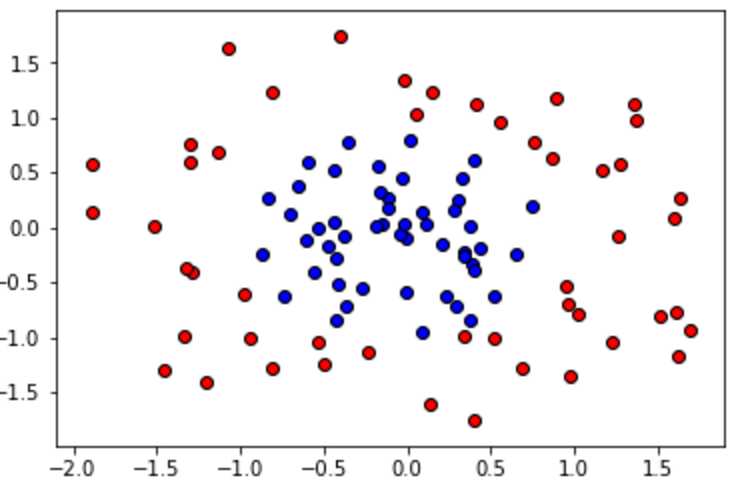

One of the models overfits, one underfits, and the other one is just right. First, we'll write some code to draw the learning curves for each model, and finally we'll look at the learning curves to decide which model is which.

First, let's remember that the way the curves look for the three models, is as follows:

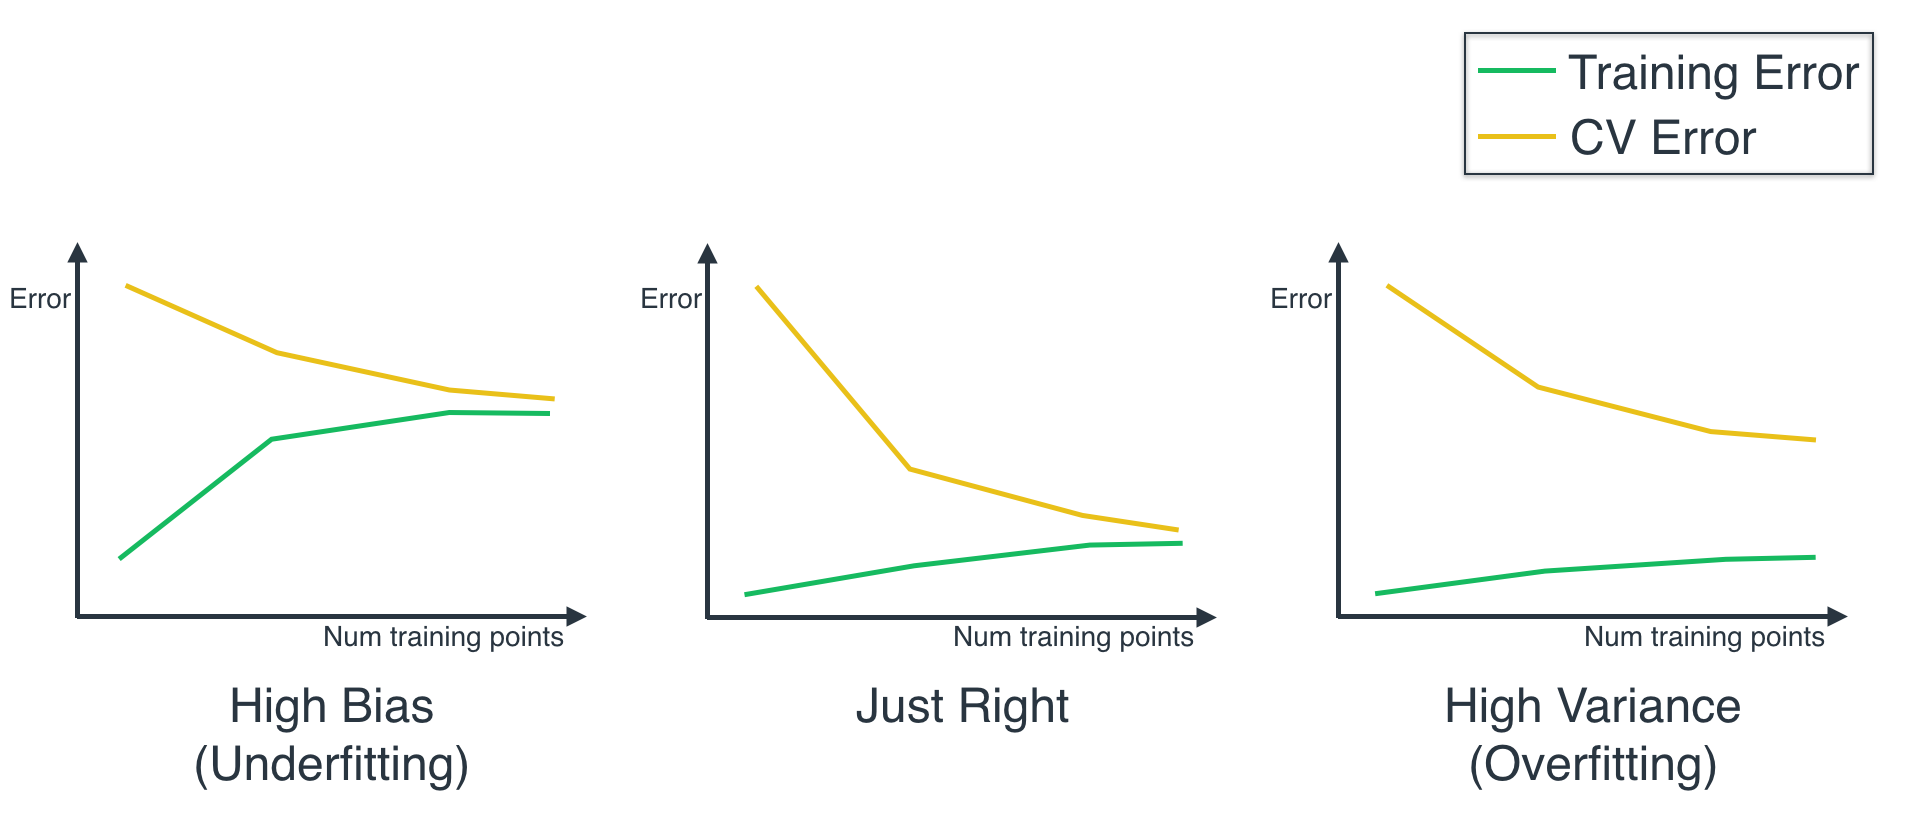

For the first part of the quiz, all you need is to uncomment one of the classifiers, and hit 'Test Run' to see the graph of the Learning Curve. But if you like coding, here are some details. We'll be using the function called <code>learning_curve</code>:

```
train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y, cv=None, n_jobs=1, train_sizes=np.linspace(.1, 1.0, num_trainings))
```

No need to worry about all the parameters of this function (you can read some more in [here](http://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html), but here we'll explain the main ones:

- <code>estimator</code>, is the actual classifier we're using for the data, e.g., <code>LogisticRegression()</code> or <code>GradientBoostingClassifier()</code>.
- <code>X</code> and <code>y</code> is our data, split into features and labels.
- <code>train_sizes</code> are the sizes of the chunks of data used to draw each point in the curve.
- <code>train_scores</code> are the training scores for the algorithm trained on each chunk of data.
- <code>test_scores</code> are the testing scores for the algorithm trained on each chunk of data.

Two very important observations:

- The training and testing scores come in as a list of 3 values, and this is because the function uses 3-Fold Cross-Validation.
- **Very important**: As you can see, we defined our curves with Training and Testing **Error**, and this function defines them with Training and Testing **Score**. These are opposite, so the higher the error, the lower the score. Thus, when you see the curve, you need to flip it upside down in your mind, in order to compare it with the curves above.

## Part 1: Drawing the learning curves

In here, we'll be comparing three models:

- A **Logistic Regression** model.
- A **Decision Tree** model.
- A **Support Vector Machine** model with an rbf kernel, and a gamma parameter of 1000 (this is another type of model, don't worry about how it works for now).

Uncomment the code for each one, and examine the learning curve that gets drawn. If you're curious about the code used to draw the learning curves, it's on the **utils.py** tab.



In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# It is good to randomize the data before drawing Learning Curves
def randomize(X, Y):
    permutation = np.random.permutation(Y.shape[0])
    X2 = X[permutation,:]
    Y2 = Y[permutation]
    return X2, Y2

# X2, y2 = randomize(X, y)

def draw_learning_curves(X, y, estimator, num_trainings):
    X2, y2 = randomize(X, y)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X2, y2, cv=None, n_jobs=1, train_sizes=np.linspace(.1, 1.0, num_trainings))

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.title("Learning Curves")
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    plt.plot(train_scores_mean, 'o-', color="g",
             label="Training score")
    plt.plot(test_scores_mean, 'o-', color="y",
             label="Cross-validation score")


    plt.legend(loc="best")

    plt.show()

In [ ]:
# Import libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%reload_ext autoreload

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

In [ ]:
# Import data from csv file
# URL for our dataset, data.csv
URL = "https://drive.google.com/file/d/1Rs5MA4alNxibrZTH6W3Q8ZorGGZUHoR3/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

data = pd.read_csv(FILE_PATH)

In [ ]:
# Fix random seed
np.random.seed(55)

# Prepare features and label data
X = np.array(data[['x1', 'x2']])
y = np.array(data['y'])

In [ ]:
# TODO: Uncomment one of the three classifiers, and hit "Test Run"
# to see the learning curve. Use these to answer the quiz below.

### Logistic Regression
# estimator = LogisticRegression()

### Decision Tree
#estimator = GradientBoostingClassifier()

### Support Vector Machine
# estimator = SVC(kernel='rbf', gamma=1000)

In [ ]:
draw_learning_curves(X, y, estimator, 10)

## Part 2: Analyzing the learning curves

For this second part of the quiz, you can look at the curves you've drawn before, to decide which one of the three models underfits, which one overfits, and which one is just right.

### Quiz Question

From the models above, which model underfits, which one overfits, and which one is just right?

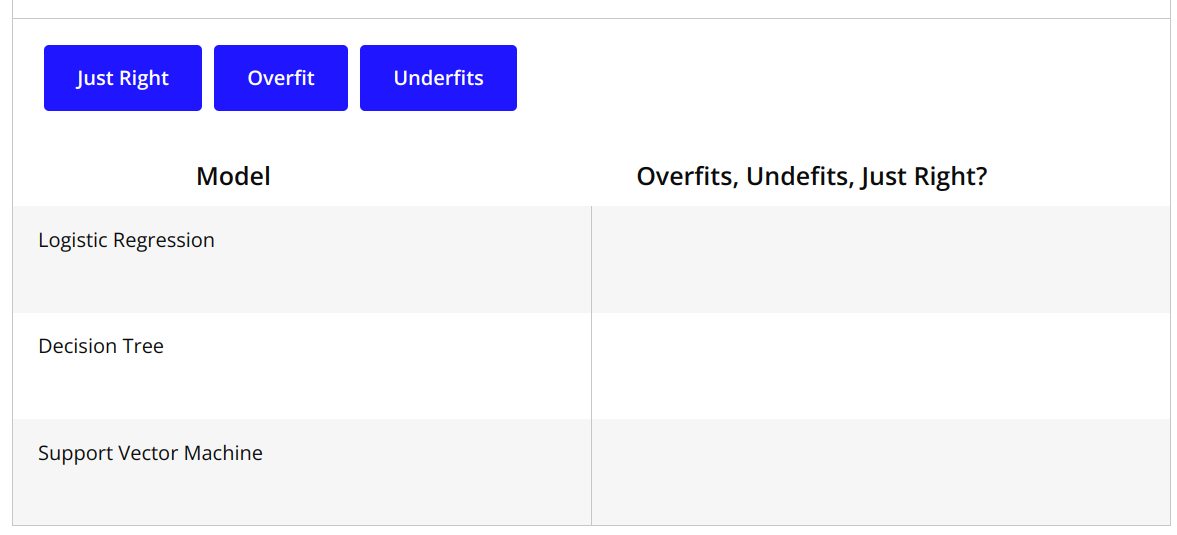

Now, we should check if this is visible in the actual model. When we plot the boundary curves for each one of these models, we get the following:

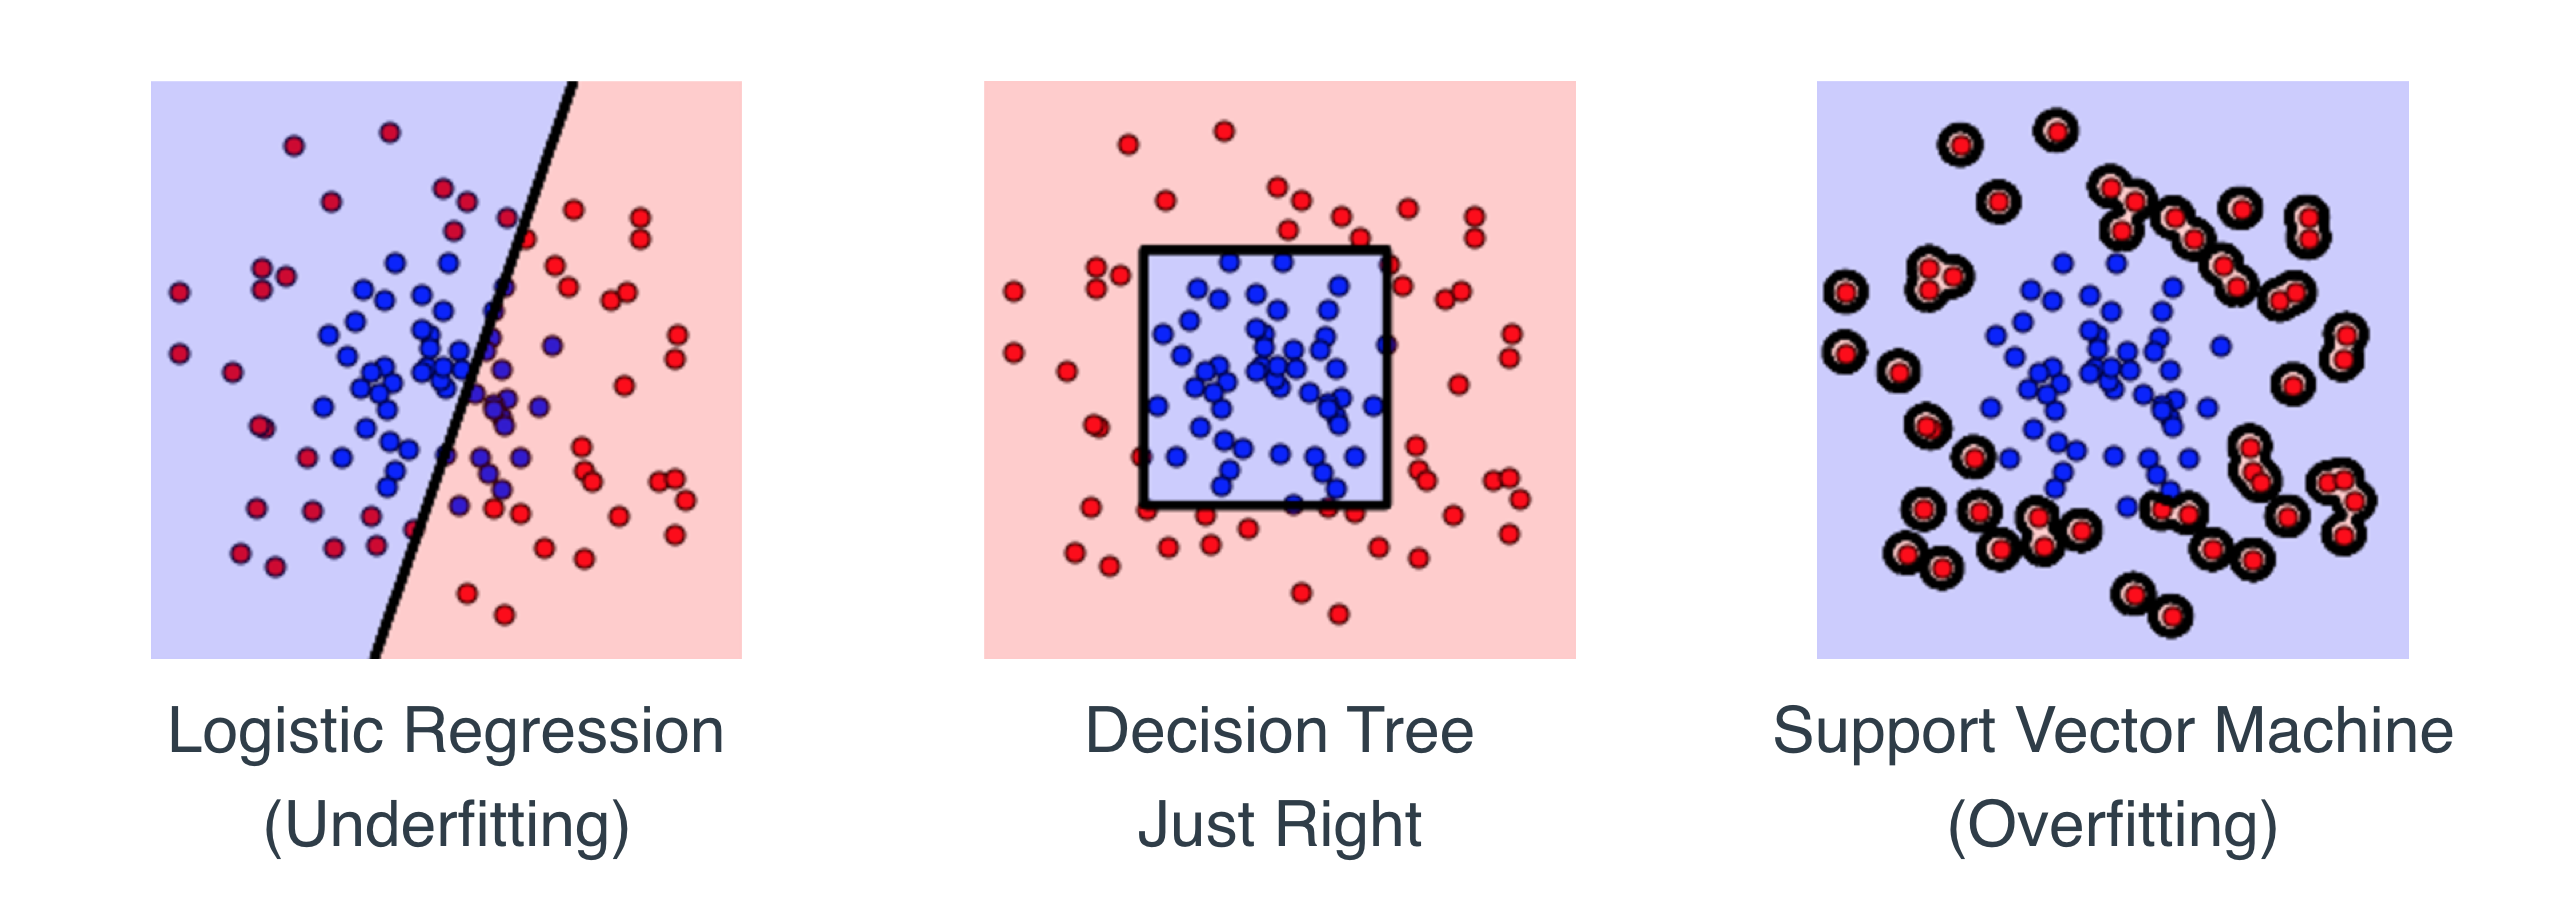

When we look at the models above, does it make sense that the first one underfits, the second one is right, and the third one overfits? It does, right? We can see that the data is correctly bounded by a circle, or a square. What our models do, is the following:

- The **Logistic Regression** model uses a line, which is too simplistic. It doesn't do very well on the training set. Thus, it **underfits**.
- The **Decision Tree** model uses a square, which is a pretty good fit and generalizes well. Thus, this model is **good**.
- The **Support Vector Machine** model actually draws a tiny circle around each point. This is clearly just memorizing the training set, and won't generalize well. Thus, it **overfits**.

It's always good to do a reality check when we can, and see that our models actually do have the behavior that the metrics tell us.